### Shape Metric Analysis, Justification and Loss Formulation Design

In [9]:
import sys
!{sys.executable} -m pip install seaborn

In [10]:
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
tile_path = "/opt/app-root/src/gregg-work/ftw-mappingafrica-integration/data/tile899177_2024-6_polygons.geojson"
gdf = gpd.read_file(tile_path)

print("Number of polygons:", len(gdf))
gdf.head()

Number of polygons: 535


,area_m2,area_ha,perimeter_m,compactness,shape_index,interior_edge,fractal_dim,tile_id,polygon_index,polygon_id,geometry
0,12408.935044,1.240894,614.277317,0.413252,1.555580,0.049503,1.362260,899177,0,899177000000,"POLYGON ((31.26008 -14.41042, 31.26002 -14.410..."
1,413.881577,0.041388,80.533450,0.801924,1.116692,0.194581,1.456681,899177,1,899177000001,"POLYGON ((31.2599 -14.41, 31.25965 -14.41, 31...."
2,182.704724,0.018270,59.905644,0.639770,1.250224,0.327882,1.571763,899177,2,899177000002,"POLYGON ((31.25975 -14.40952, 31.25982 -14.409..."
3,618.969419,0.061897,105.080754,0.704422,1.191471,0.169767,1.448254,899177,3,899177000003,"POLYGON ((31.26062 -14.40582, 31.2604 -14.4058..."
4,6335.182466,0.633518,333.289473,0.716681,1.181237,0.052609,1.327186,899177,4,899177000004,"POLYGON ((31.25962 -14.4031, 31.2597 -14.40305..."


In [5]:
print(gdf.columns)

Index(['area_m2', 'area_ha', 'perimeter_m', 'compactness', 'shape_index',
       'interior_edge', 'fractal_dim', 'tile_id', 'polygon_index',
       'polygon_id', 'geometry'],
      dtype='object')


In [6]:
metrics = ["compactness", "shape_index", "fractal_dim", "interior_edge"]

gdf[metrics].describe()

,compactness,shape_index,fractal_dim,interior_edge
count,535.000000,535.000000,535.000000,535.000000
mean,0.538232,1.564506,1.367834,0.073916
std,0.228393,0.709692,0.074137,0.077727
min,0.020927,1.033933,1.244301,0.014950
25%,0.360233,1.170112,1.315277,0.030483
50%,0.579865,1.313217,1.350249,0.042895
75%,0.730374,1.666128,1.399914,0.076271
max,0.935439,6.912624,1.756038,0.539851


In [7]:
gdf[metrics].var().sort_values(ascending=False)

shape_index      0.503663
compactness      0.052164
interior_edge    0.006041
fractal_dim      0.005496
dtype: float64

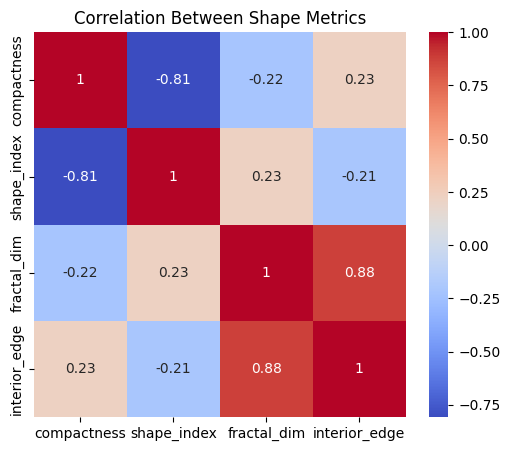

In [11]:
corr = gdf[metrics].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Between Shape Metrics")
plt.show()

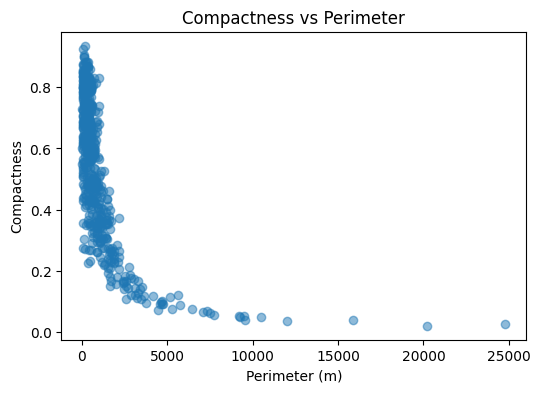

In [12]:
plt.figure(figsize=(6,4))
plt.scatter(gdf["perimeter_m"], gdf["compactness"], alpha=0.5)
plt.xlabel("Perimeter (m)")
plt.ylabel("Compactness")
plt.title("Compactness vs Perimeter")
plt.show()

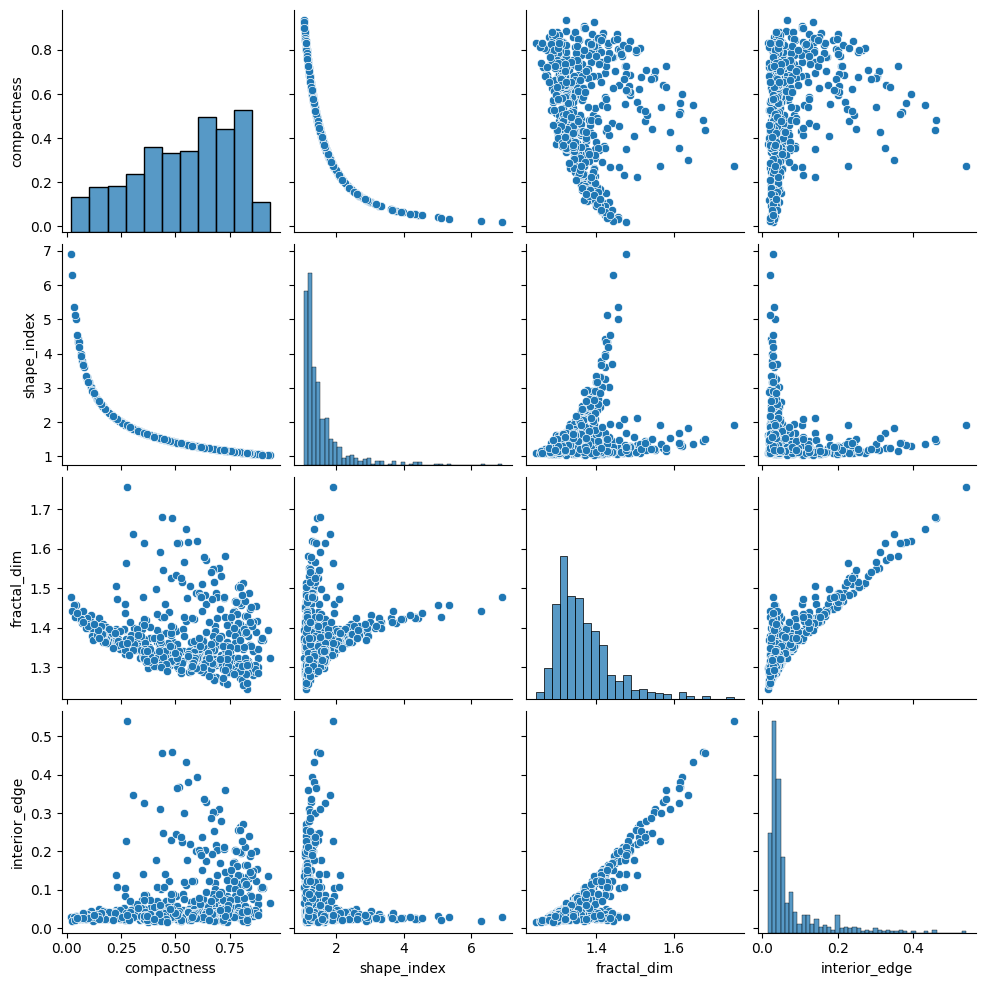

In [13]:
sns.pairplot(gdf[metrics])
plt.show()

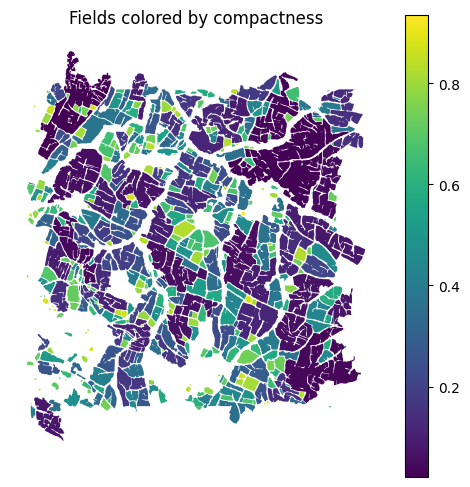

In [14]:
fig, ax = plt.subplots(figsize=(6,6))

gdf.plot(
    column="compactness",
    cmap="viridis",
    legend=True,
    ax=ax
)

ax.set_title("Fields colored by compactness")
ax.axis("off")
plt.show()

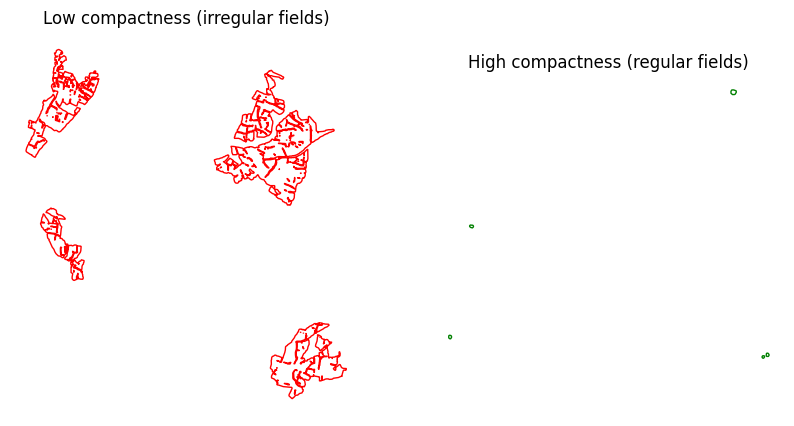

In [15]:
low = gdf.nsmallest(5, "compactness")
high = gdf.nlargest(5, "compactness")

fig, axes = plt.subplots(1, 2, figsize=(10,5))

low.plot(ax=axes[0], edgecolor="red", facecolor="none")
axes[0].set_title("Low compactness (irregular fields)")

high.plot(ax=axes[1], edgecolor="green", facecolor="none")
axes[1].set_title("High compactness (regular fields)")

for ax in axes:
    ax.axis("off")

plt.show()

### Empirical Justification for Selecting Compactness

To determine the most appropriate shape metric for guiding geometric regularization, we analyzed polygon-level metrics including compactness, shape index, fractal dimension, and interior edge.

#### Metric variability and stability

From the statistical analysis, shape index exhibits the highest variance, indicating strong sensitivity to geometric differences. However, it also produces extreme outliers (values up to ~6.9), making it unstable and less suitable for optimization in a learning framework.

Compactness, in contrast, shows moderate variance and a well-bounded range (~0.02 to 0.93), indicating that it captures meaningful geometric variation while remaining numerically stable. Other metrics such as fractal dimension and interior edge show very low variance, suggesting limited discriminative power.

#### Correlation analysis

The correlation matrix shows a strong negative relationship between compactness and shape index (-0.81), indicating that both metrics capture similar notions of geometric irregularity but in opposite directions. However, compactness is more interpretable and bounded.

Fractal dimension and interior edge are highly correlated (0.88), suggesting redundancy between these metrics. In contrast, compactness shows only weak correlation with these metrics, indicating that it captures complementary geometric information.

#### Relationship with boundary complexity

The scatter plot of compactness versus perimeter reveals a clear inverse relationship: as perimeter increases, compactness decreases sharply. This confirms that compactness effectively penalizes boundary complexity and irregularity, which is central to the objective of improving field geometry.

#### Visual interpretation

Spatial visualization further supports this interpretation. Fields with low compactness values correspond to highly irregular, fragmented, and jagged shapes, while fields with high compactness values are smooth and geometrically coherent. This is clearly illustrated in the extreme-case comparisons.

#### Conclusion

Overall, compactness provides the best balance between:
- sensitivity to geometric irregularity,
- numerical stability,
- interpretability, and
- alignment with the objective of penalizing complex boundaries.

For these reasons, compactness was selected as the primary metric to guide the soft compactness loss in this work.

### Prediction–Label Comparison Strategy and Loss Design

After selecting compactness as the primary shape metric, the next step is to define how predicted field geometries should be compared with label geometries.

There are three possible comparison strategies (Focus is one first 2):

1. **Average metric value per chip**  
   Compute the mean compactness of all predicted fields in a chip and compare it with the mean compactness of all label fields in the same chip. This is simple and stable, but it loses object-level detail.

2. **Distribution summary comparison**  
   Compare summary statistics such as mean, median, variance, and quantiles of compactness between predictions and labels. This better captures whether the prediction distribution resembles the label distribution, but it still does not require one-to-one matching between objects.

3. **Per-object nearest matching**  
   Match predicted polygons to label polygons using spatial overlap or nearest-neighbor relationships, then compare compactness object-by-object. This is the most detailed strategy, but it is more complex and can be unstable when predictions are fragmented, merged, or missing.

For the loss design, we use a differentiable approximation of the first two strategies. Instead of polygonizing predictions during training, the model computes a soft field probability map. From this probability map, we estimate soft area and soft perimeter, then derive a compactness-related shape irregularity term. This allows the model to receive a shape-based penalty during training while remaining fully differentiable.

The loss therefore compares the predicted soft shape irregularity with the label-derived shape irregularity. Empty-field cases are handled explicitly: if both prediction and label contain no fields, the compactness penalty is zero; if one is empty and the other is not, the model is penalized for false field presence or absence.

### Soft Compactness Loss Formulation

The compactness metric is traditionally defined as:

\[
C = \frac{4\pi A}{P^2}
\]

where \(A\) is polygon area and \(P\) is polygon perimeter. Higher values indicate more compact shapes, while lower values indicate irregular or elongated shapes.

For training, we use the inverse form:

\[
I = \frac{P^2}{4\pi A}
\]

where \(I\) represents shape irregularity. This inverse form is useful because larger values correspond to more irregular shapes, making it easier to interpret as a penalty.

Since polygonization is not differentiable, area and perimeter are estimated directly from the soft probability map. Soft area is computed as the sum of field probabilities, while soft perimeter is approximated using spatial gradients in the probability map.

The final soft compactness term compares predicted and label shape irregularity using a log-scaled absolute difference:

\[
L_{compactness} = \left| \log(1 + I_{pred}) - \log(1 + I_{label}) \right|
\]

This compactness term is then added to the locally weighted Tversky focal loss:

\[
L_{total} = L_{Tversky} + \lambda L_{compactness}
\]

This design encourages the model to optimize both pixel-level class accuracy and geometric field regularity.

### Below is an intuitive explanation of the probability map, the gradient and soft perimeter used for the soft compactness

**Figure 1: Probability map representation of a field**

The model predicts a probability map where each pixel represents the likelihood of belonging to a field (values close to 1) or background (values close to 0). The transition between these regions defines the field boundary.

All Images Generated with **Claude AI**

[![Screenshot-2026-05-04-010321.png](https://i.postimg.cc/Cx4HzB8j/Screenshot-2026-05-04-010321.png)](https://postimg.cc/bZs25v3J)

**Figure 2: Gradient captures boundary locations**

The spatial gradient measures how much pixel values change. Large gradients occur only at locations where the probability sharply transitions from background (0) to field (1), effectively identifying boundary pixels.

[![Screenshot-2026-05-04-010332.png](https://i.postimg.cc/Cx4HzB8G/Screenshot-2026-05-04-010332.png)](https://postimg.cc/zyVRQf0v)

**Figure 3: Soft perimeter from summed gradients**

By summing gradient magnitudes across the image, we obtain a differentiable approximation of the perimeter. Interior and background pixels contribute little, while boundary pixels contribute strongly.

[![Screenshot-2026-05-04-010359.png](https://i.postimg.cc/qvGXzhKX/Screenshot-2026-05-04-010359.png)](https://postimg.cc/MnvjLGdv)

**Figure 4: Gradient magnitude combines horizontal and vertical changes**

The gradient is computed in both horizontal (dx) and vertical (dy) directions. The magnitude √(dx² + dy²) ensures that edges are captured regardless of their orientation, including vertical, horizontal and diagonal boundaries.

[![Screenshot-2026-05-04-010508.png](https://i.postimg.cc/L8VBnYPk/Screenshot-2026-05-04-010508.png)](https://postimg.cc/18fNdzJ4)